# 04 — From a table to a model you can defend

**Rahnema College ML Bootcamp 1405** · Week 3 · Peyman Naseri

---

## Where we are

Two weeks ago we drew the map of a data science project — nine stages, in
[`02_data_science_pipeline.ipynb`](02_data_science_pipeline.ipynb):

> problem → collect → **clean** → **EDA** → **model** → **evaluate** → deploy → monitor → report

Last week, with NumPy, pandas and matplotlib, we did the EDA properly and
touched the edge of preprocessing. Today we finish the middle of that map, and
for it we need one more library: **scikit-learn**.

## How this notebook works

Same shape as the NumPy and pandas notebooks: each section opens with a **sheet**
you can keep, then a set of **small examples you can run and break**. Some I
will walk through; the rest are there for you afterwards.

| section | what it covers |
|---|---|
| 1 | scikit-learn: one interface for everything |
| 2 | preprocessing: the menu for a single column |
| 3 | features: making columns that were not there |
| 4 | `ColumnTransformer` and `Pipeline` |
| 5 | fitting a model, and a baseline to beat |
| 6 | four ways a score lies to you |
| 7 | which cross-validation split |
| 8 | metrics, and what each one hides |
| 9 | error analysis |

Notebook 05 then takes all of it to a real forecasting problem.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"
import sys
sys.path.insert(0, str(ROOT))
from bootcamp import (sklearn_api, preprocessing_sheet, scaling_matters,
                      pipeline_anatomy, feature_families, leakage_gallery,
                      cv_schemes, metrics_sheet)

plt.rcParams.update({"figure.figsize": (11, 4), "figure.dpi": 110, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
sns.set_theme(style="whitegrid", rc=plt.rcParams)

# One seed for the whole notebook, so your numbers match mine.
SEED = 3

# A small delivery dataset: an order is placed, how many minutes until it
# arrives? 12,000 rows, so every cell below runs in about a second.
deliveries = pd.read_csv(DATA / "deliveries.csv", parse_dates=["order_time"])
print(f"{len(deliveries):,} orders, {deliveries.shape[1]} columns")
deliveries.head(3)

12,000 orders, 15 columns


,order_id,order_time,store,customer_id,courier_id,courier_type,weather,basket_size,basket_value_toman,distance_km,prep_minutes,actual_route_km,rating,tip_toman,delivery_minutes
0,510849,2025-09-01 11:16:00,Vakilabad,U02396,C0061,motorcycle,clear,7,992000,1.50,10.7,2.74,4.0,38000,15.0
1,500138,2025-09-01 11:41:00,Gohardasht,U02062,C0017,motorcycle,clear,5,1236000,1.46,6.4,1.61,4.0,0,19.1
2,501157,2025-09-01 12:33:00,Vakilabad,U02021,C0199,motorcycle,clear,5,474000,3.64,7.7,3.64,4.0,45000,26.3


---

# 1. scikit-learn: one interface for everything

NumPy gave us arrays, pandas gave us labelled tables. scikit-learn gives us
**one interface for every model and every transformation** — and that
consistency, not any particular algorithm, is the reason it is the standard.

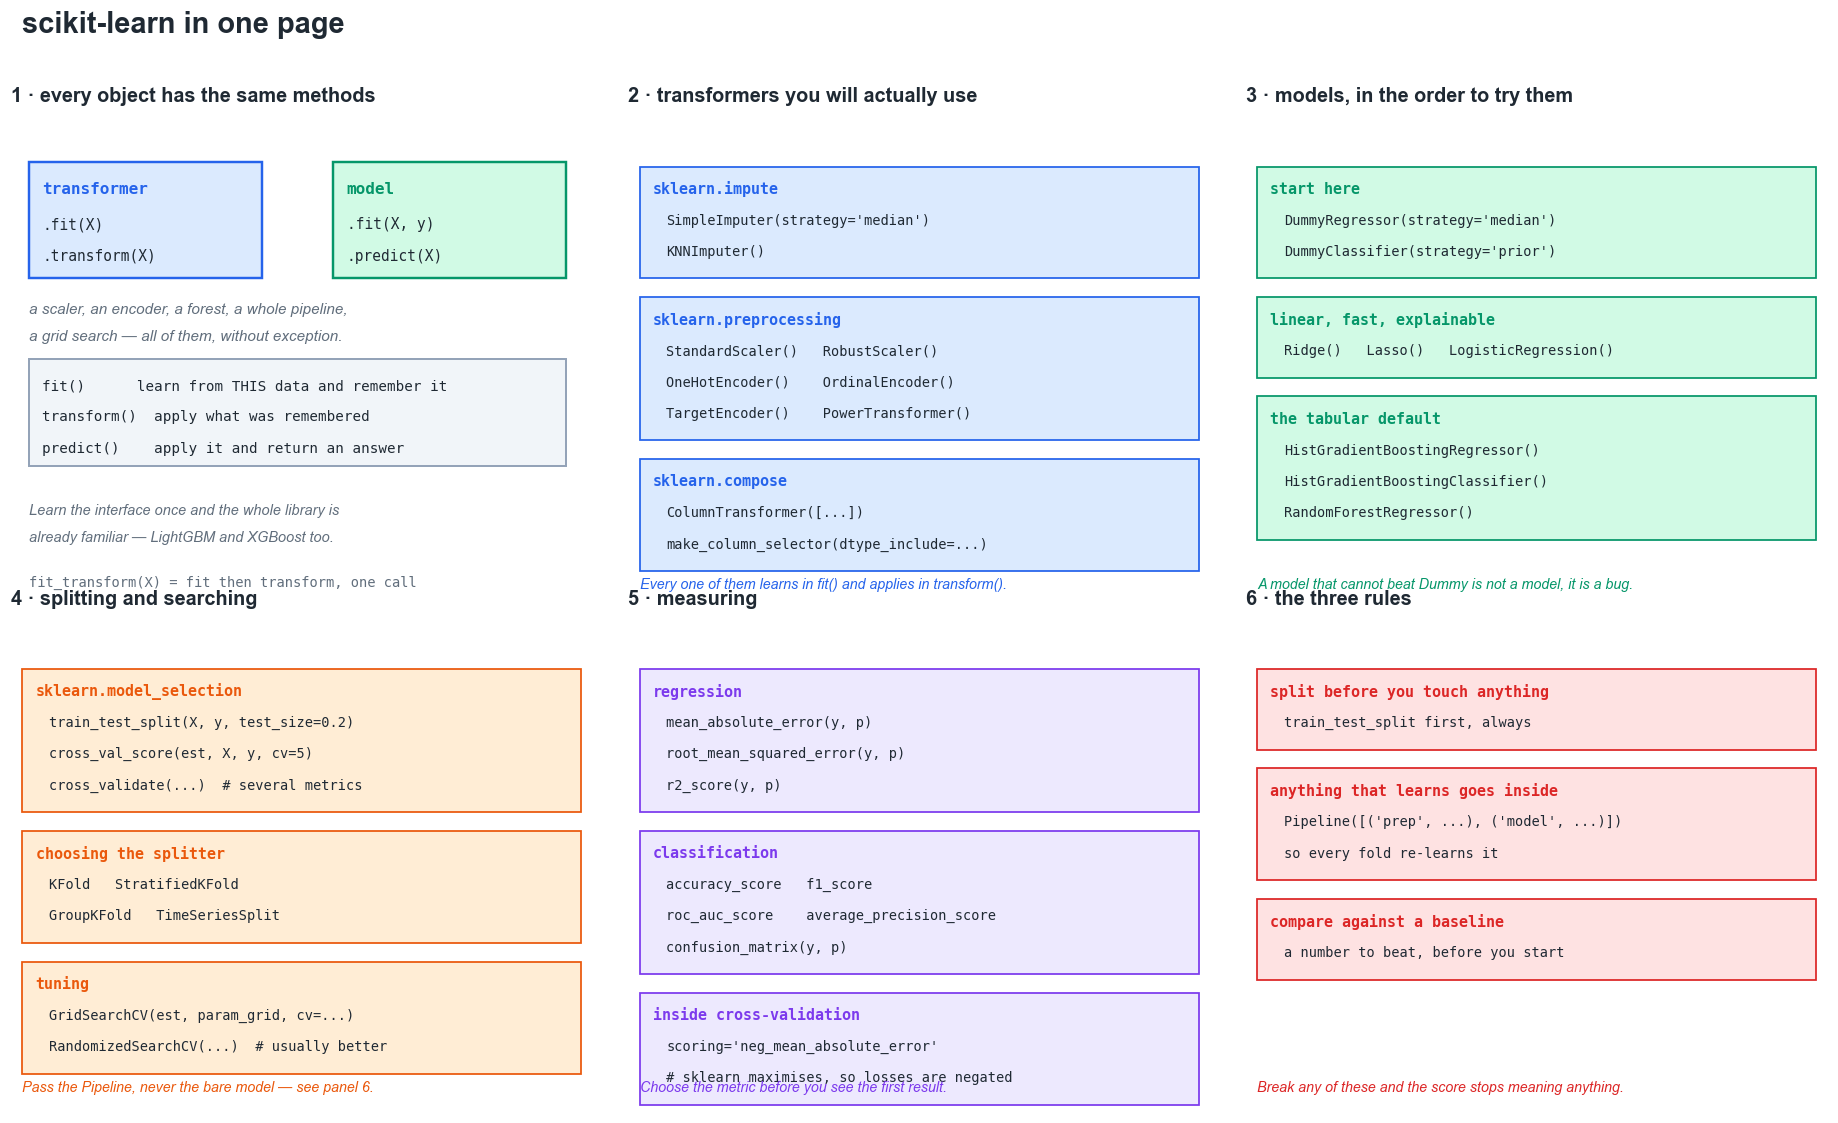

In [2]:
sklearn_api();   # also assets/sklearn_api.png

### The interface, on three objects that have nothing in common

A scaler, an encoder and a model. Watch how the code barely changes.

In [3]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge

x = deliveries[["distance_km"]].head(500)
w = deliveries[["weather"]].head(500).fillna("unknown")
y = deliveries["delivery_minutes"].head(500)

# A transformer: learns in fit(), applies in transform().
scaler = StandardScaler()
scaler.fit(x)                       # learns the mean and the sd
print("learned mean:", scaler.mean_.round(2), "  sd:", scaler.scale_.round(2))
print("first 3 scaled:", scaler.transform(x)[:3].ravel().round(2))

# Another transformer. Same two methods, completely different job.
encoder = OneHotEncoder(sparse_output=False)
encoder.fit(w)                      # learns which categories exist
print("\nlearned categories:", encoder.categories_[0])

# A model: fit(X, y) then predict(X). Still the same shape.
model = Ridge()
model.fit(x, y)
print("\npredicted minutes for the first 3 orders:", model.predict(x)[:3].round(1))

learned mean: [2.39]   sd: [1.12]
first 3 scaled: [-0.79 -0.82  1.12]

learned categories: ['clear' 'rain' 'snow' 'unknown']

predicted minutes for the first 3 orders: [20.5 20.3 30.5]


`fit_transform(X)` is just `fit` then `transform` in one call. Use it on the
training data; use plain `transform` everywhere else, because everywhere else
must not re-learn anything.

In [4]:
# Why the distinction matters, in four lines.
train_col = pd.DataFrame({"v": [10.0, 20, 30, 40]})
test_col = pd.DataFrame({"v": [100.0]})

s = StandardScaler()
print("train, fit_transform:", s.fit_transform(train_col).ravel().round(2))
# transform() reuses the mean and sd learned above -- 100 is far out, and the
# scaled value says so. That is the correct behaviour.
print("test,  transform    :", s.transform(test_col).ravel().round(2))
# If we had called fit_transform on the test set instead, it would have
# recentred on 100 and the outlier would vanish:
print("test,  fit_transform:", StandardScaler().fit_transform(test_col).ravel())
print("\n^ the last line is the bug. The test set must never re-fit anything.")

train, fit_transform: [-1.34 -0.45  0.45  1.34]
test,  transform    : [6.71]
test,  fit_transform: [0.]

^ the last line is the bug. The test set must never re-fit anything.


### 💡 Try it yourself

1. Fit a `MinMaxScaler` on `train_col` and transform `test_col`. What happens
   to a value outside the training range, and is that a problem?
2. `encoder.transform` on a category it has never seen raises by default. Set
   `handle_unknown="ignore"` and try again — what row do you get back?
3. `Ridge` has a `.coef_` after fitting. Fit it on two columns instead of one
   and see whether the coefficients are comparable. Then scale first and look
   again.

---

# 2. Preprocessing: the menu for one column

Before the menu, the two rules that make everything after it safe:

**Split first.** The moment you compute anything from the full dataset — a
median to fill with, a scaler's mean, a list of categories — your test set has
touched the model and the score stops being honest.

**Anything that learns goes inside the Pipeline** (section 4). If a step looks
at the data to decide what to do, it has to be re-learned on every training
fold.

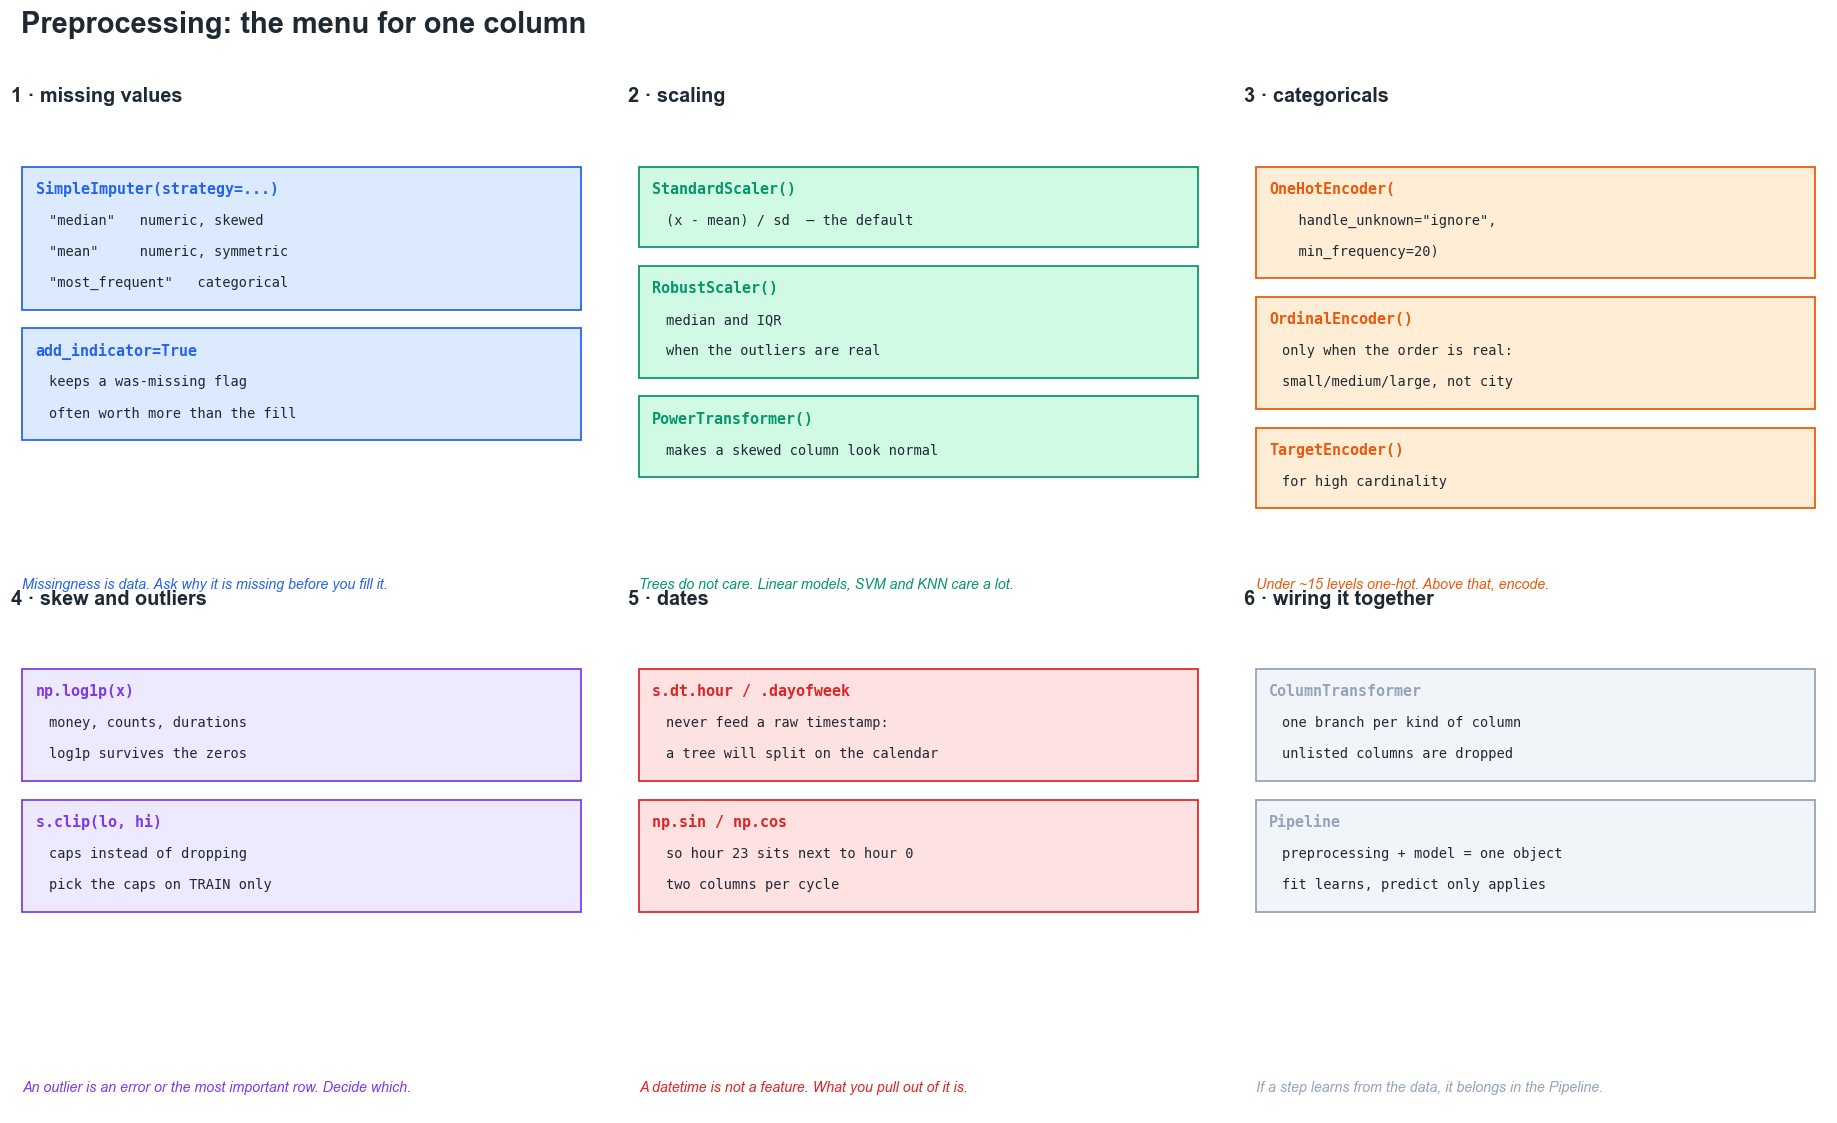

In [5]:
preprocessing_sheet();   # also assets/preprocessing_sheet.png

### 2.1 Missing values

The imputer learns a number in `fit` and reuses it forever. That number comes
from the training data only — which is the whole reason it is an estimator and
not a call to `.fillna()`.

In [6]:
from sklearn.impute import SimpleImputer

prep = deliveries[["prep_minutes"]]
print("missing:", int(prep.isna().sum().iloc[0]), "of", len(prep))

imputer = SimpleImputer(strategy="median")
filled = imputer.fit_transform(prep)
print("learned median:", imputer.statistics_[0].round(2))
print("missing after :", int(np.isnan(filled).sum()))

missing: 240 of 12000
learned median: 6.6
missing after : 0


In [7]:
# The flag is often worth more than the fill. add_indicator appends a 0/1
# column saying "this value was missing", so the model can use the fact.
flagged = SimpleImputer(strategy="median", add_indicator=True).fit_transform(prep)
print("columns out:", flagged.shape[1], " (the value, then the was-missing flag)")
print(pd.DataFrame(flagged, columns=["prep_minutes", "was_missing"]).head(3).to_string(index=False))

# Is the flag informative here? Compare the target for missing vs present.
missing = prep["prep_minutes"].isna()
print(f"\nmean delivery when prep_minutes is present: "
      f"{deliveries.loc[~missing, 'delivery_minutes'].mean():.2f} min")
print(f"mean delivery when prep_minutes is missing: "
      f"{deliveries.loc[missing, 'delivery_minutes'].mean():.2f} min")

columns out: 2  (the value, then the was-missing flag)
 prep_minutes  was_missing
         10.7          0.0
          6.4          0.0
          7.7          0.0

mean delivery when prep_minutes is present: 21.16 min
mean delivery when prep_minutes is missing: 21.55 min


Here the two means are close, so the flag carries little — this dataset drops
`prep_minutes` at random. On real data it usually is not random, and the flag
earns its column. Notebook 05 has a case where a missingness flag turned out to
be the single most valuable feature in the model.

### 2.2 Scaling

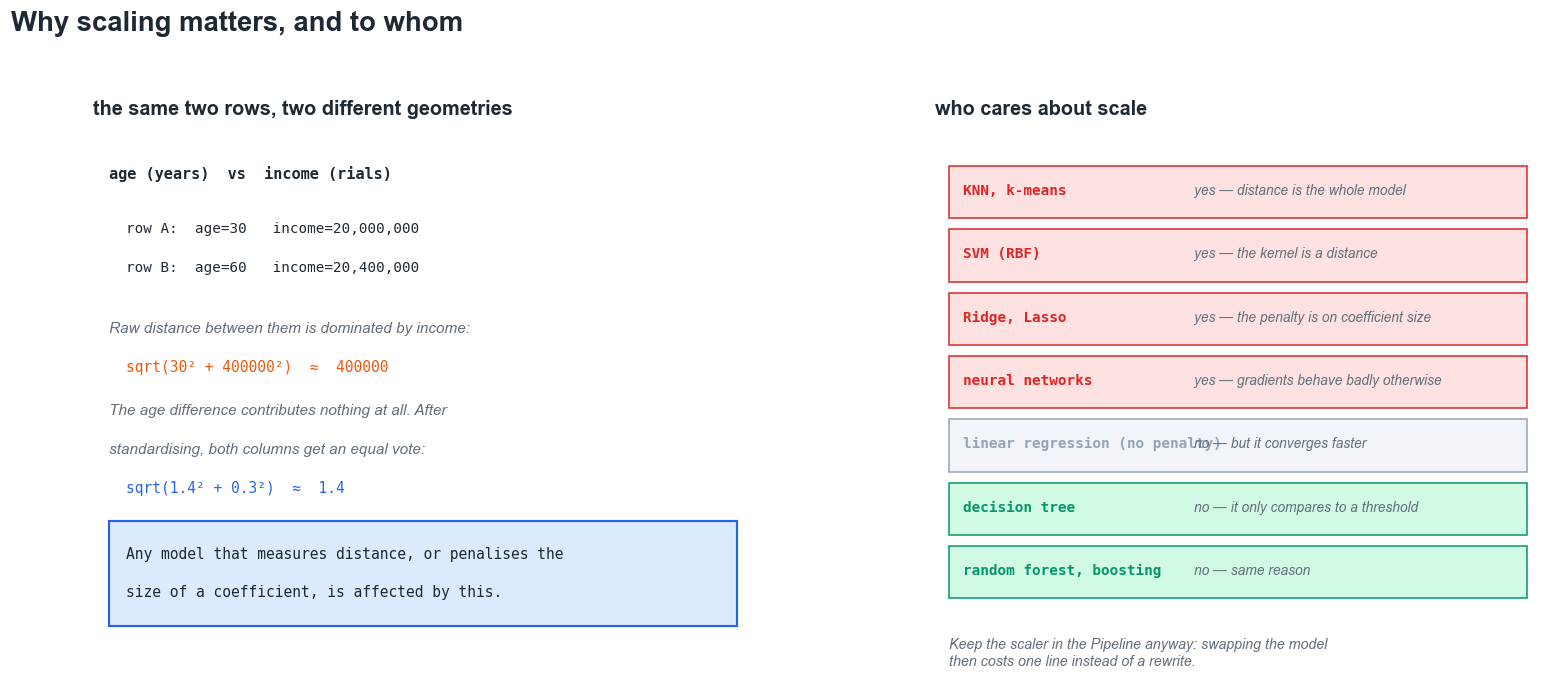

In [8]:
scaling_matters();   # also assets/scaling_matters.png

In [9]:
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score

# Two columns on wildly different scales: kilometres and rials.
X = deliveries[["distance_km", "basket_value_toman"]].head(4000)
y = deliveries["delivery_minutes"].head(4000)

def mae_of(estimator):
    """Mean absolute error under 5-fold CV, as a positive number."""
    return -cross_val_score(estimator, X, y, cv=5,
                            scoring="neg_mean_absolute_error").mean()

print("KNN  — a distance-based model")
print(f"   raw    : {mae_of(KNeighborsRegressor()):.2f} min")
print(f"   scaled : {mae_of(make_pipeline(StandardScaler(), KNeighborsRegressor())):.2f} min")

print("\nDecision tree — only ever compares to a threshold")
print(f"   raw    : {mae_of(DecisionTreeRegressor(max_depth=6, random_state=SEED)):.2f} min")
print(f"   scaled : {mae_of(make_pipeline(StandardScaler(), DecisionTreeRegressor(max_depth=6, random_state=SEED))):.2f} min")

KNN  — a distance-based model
   raw    : 6.64 min
   scaled : 5.35 min

Decision tree — only ever compares to a threshold


   raw    : 5.04 min


   scaled : 5.04 min


The KNN number moves a lot; the tree does not move at all. That is the whole
rule, measured: **scaling matters when the model measures distance or penalises
coefficient size, and is irrelevant to trees.**

Keep the scaler in the pipeline regardless — swapping a tree for a Ridge then
costs one line instead of a rewrite.

      standard  robust  minmax
mean     -0.00    0.22    0.11
std       1.00    0.91    0.08
min      -1.41   -1.05    0.00
max      11.00   10.22    1.00


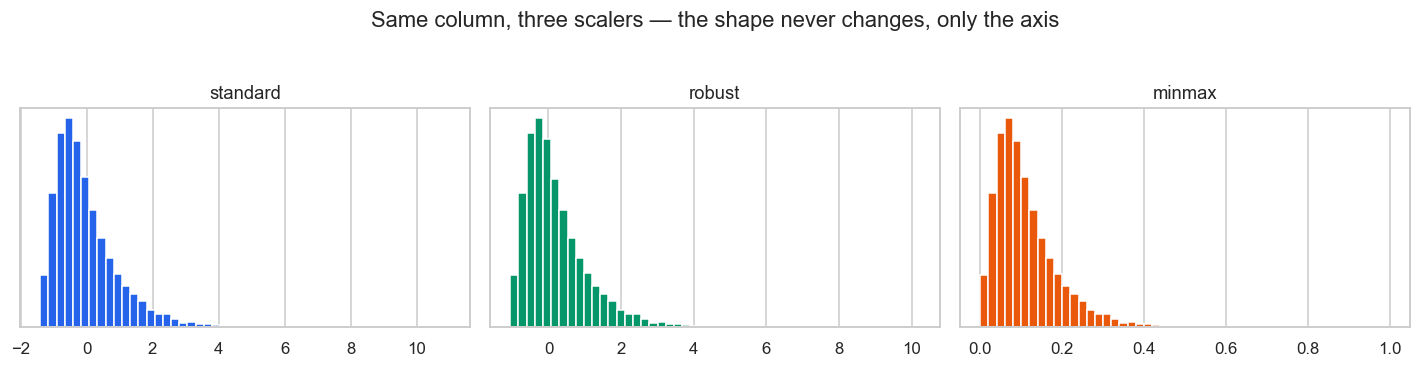

In [10]:
# Standard vs Robust, on a column with a long right tail.
money = deliveries[["basket_value_toman"]]
comparison = pd.DataFrame({
    "standard": StandardScaler().fit_transform(money).ravel(),
    "robust": RobustScaler().fit_transform(money).ravel(),
    "minmax": MinMaxScaler().fit_transform(money).ravel(),
})
print(comparison.describe().loc[["mean", "std", "min", "max"]].round(2).to_string())

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, col, colour in zip(axes, comparison.columns, ["#2563eb", "#059669", "#ea580c"]):
    ax.hist(comparison[col], bins=50, color=colour)
    ax.set(title=col, yticks=[])
fig.suptitle("Same column, three scalers — the shape never changes, only the axis", y=1.04)
fig.tight_layout()

Notice the shape is identical in all three. **Scaling moves and stretches a
column; it does not make it symmetric.** For that you need a transform, which
is the next section.

### 2.3 Skew

log(0)   -> -inf
log1p(0) -> 0.0


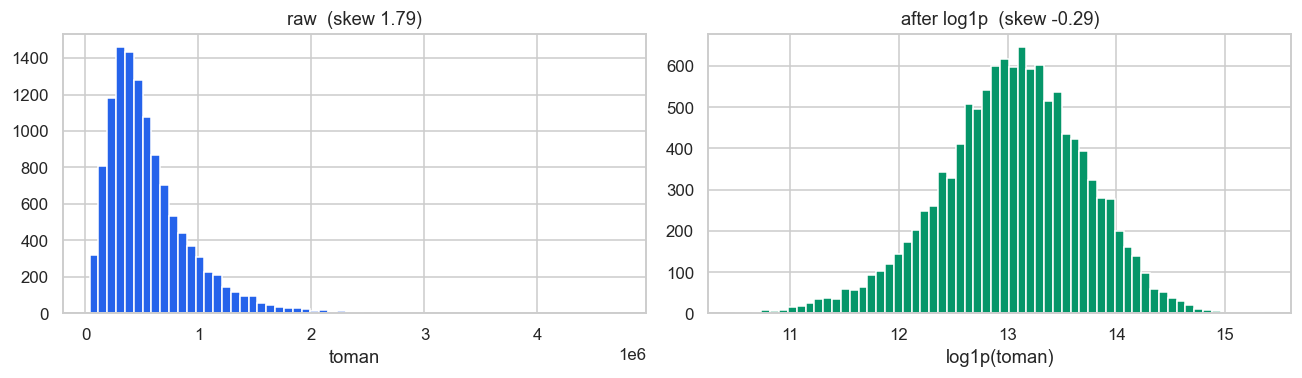

In [11]:
value = deliveries["basket_value_toman"]

fig, (ax_raw, ax_log) = plt.subplots(1, 2, figsize=(12, 3.6))
ax_raw.hist(value, bins=60, color="#2563eb")
ax_raw.set(title=f"raw  (skew {value.skew():.2f})", xlabel="toman")
ax_log.hist(np.log1p(value), bins=60, color="#059669")
ax_log.set(title=f"after log1p  (skew {np.log1p(value).skew():.2f})", xlabel="log1p(toman)")
fig.tight_layout()

# log1p, not log: it computes log(1 + x), so a zero stays a zero instead of
# becoming -inf. Money columns are full of zeros, so this matters.
with np.errstate(divide="ignore"):      # we are triggering the warning on purpose
    print("log(0)   ->", np.log(0.0))
print("log1p(0) ->", np.log1p(0.0))

### 2.4 Categoricals

In [12]:
weather = deliveries[["weather"]].fillna("unknown")

# handle_unknown="ignore" is not optional. Without it, a category that appears
# only at predict time raises -- in production, at 2am.
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
enc.fit(weather)
print("categories:", list(enc.categories_[0]))
print("a never-seen category becomes all zeros:",
      enc.transform(pd.DataFrame({"weather": ["hail"]})))

# min_frequency folds rare levels into one bucket, which keeps the column
# count sane when cardinality is high.
counts = weather["weather"].value_counts()
print("\nlevel counts:\n" + counts.to_string())
grouped = OneHotEncoder(min_frequency=1000, sparse_output=False).fit(weather)
print("\nwith min_frequency=1000 ->", list(grouped.get_feature_names_out()))

categories: ['clear', 'rain', 'snow', 'unknown']
a never-seen category becomes all zeros: [[0. 0. 0. 0.]]

level counts:
weather
clear      8920
rain       1845
unknown     900
snow        335

with min_frequency=1000 -> ['weather_clear', 'weather_rain', 'weather_infrequent_sklearn']


### 💡 Try it yourself

4. Build a column with 200 distinct values and one-hot it. How many columns do
   you get? Now set `min_frequency=5`.
5. `OrdinalEncoder` turns categories into 0, 1, 2… Try it on `weather` and then
   fit a `Ridge`. What has the model been told about the relationship between
   clear, rain and snow that is not true?
6. Winsorise `basket_value_toman` at its 1st and 99th percentiles with
   `.clip()`. Compute the percentiles on the **first 8,000 rows only**, then
   apply to all of them. Why that order?

---

# 3. Features: columns that were not there

Preprocessing makes existing columns usable. **Feature engineering creates new
ones**, and on tabular problems it is almost always where the gains are. No
library can do it for you, because it needs to know what the data means.

There is no universal recipe — a churn problem, an image problem and a
forecasting problem want completely different features. What there is, is a
small set of moves that keep coming back.

In [13]:
# Four moves that cover most of what people build on a table like this.
d = deliveries.head(2000).copy()

# 1. RATIOS. Two columns often mean more as one.
d["value_per_item"] = d["basket_value_toman"] / d["basket_size"]

# 2. PARTS OF A DATE. A raw timestamp is useless to a model; a tree will
#    happily split on "before 3 March" and memorise the calendar.
d["hour"] = d["order_time"].dt.hour
d["weekday"] = d["order_time"].dt.dayofweek
d["is_weekend"] = d["weekday"].isin([3, 4]).astype(int)   # Thu/Fri here

# 3. CYCLICAL ENCODING. Hour 23 and hour 0 are one apart in reality and 23
#    apart as numbers. Sine and cosine fix that.
d["hour_sin"] = np.sin(2 * np.pi * d["hour"] / 24)
d["hour_cos"] = np.cos(2 * np.pi * d["hour"] / 24)

# 4. GROUP STATISTICS. How does this row compare with its own group?
store_mean = d.groupby("store")["distance_km"].transform("mean")
d["distance_vs_store"] = d["distance_km"] / store_mean

print(d[["basket_size", "value_per_item", "hour", "hour_sin", "hour_cos",
         "distance_vs_store"]].head(4).round(3).to_string(index=False))

 basket_size  value_per_item  hour  hour_sin  hour_cos  distance_vs_store
           7      141714.286    11     0.259    -0.966              0.619
           5      247200.000    11     0.259    -0.966              0.605
           5       94800.000    12     0.000    -1.000              1.501
           7      215000.000    12     0.000    -1.000              0.858


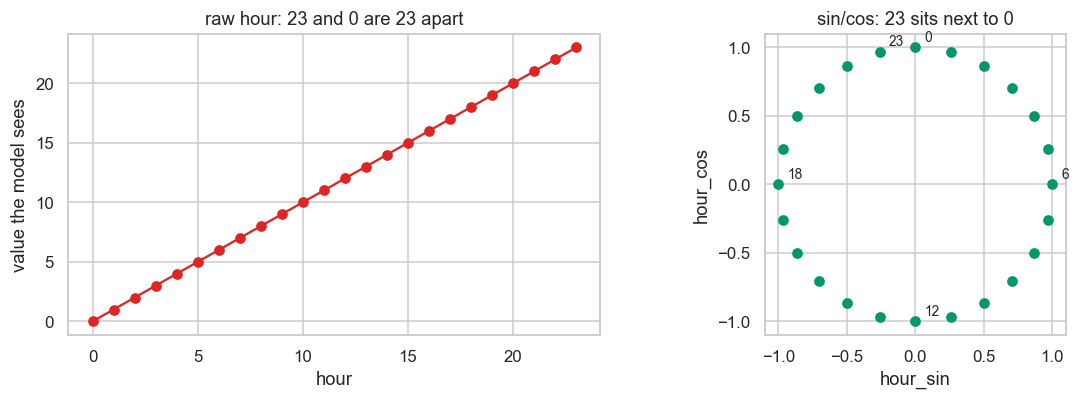

In [14]:
# Why cyclical encoding is not decoration: as a plain number, midnight is as
# far from 23:00 as it is from 01:00 is from 00:00 -- which is wrong.
hours = np.arange(24)
fig, (ax_line, ax_circle) = plt.subplots(1, 2, figsize=(11, 3.8))
ax_line.plot(hours, hours, "o-", color="#dc2626")
ax_line.set(xlabel="hour", ylabel="value the model sees",
            title="raw hour: 23 and 0 are 23 apart")
ax_circle.plot(np.sin(2*np.pi*hours/24), np.cos(2*np.pi*hours/24), "o", color="#059669")
for h in (0, 6, 12, 18, 23):
    ax_circle.annotate(str(h), (np.sin(2*np.pi*h/24), np.cos(2*np.pi*h/24)),
                       textcoords="offset points", xytext=(6, 4), fontsize=9)
ax_circle.set(xlabel="hour_sin", ylabel="hour_cos", title="sin/cos: 23 sits next to 0")
ax_circle.set_aspect("equal")
fig.tight_layout()

### The rule that outranks all of them

Whatever you build, it has to be computable **at the moment you would make the
prediction**. A feature that quietly uses information from later is the most
expensive mistake in this notebook, and section 6 is entirely about it.

For panel data — one row per entity per time period, which is most industrial
tabular work — there is a proper taxonomy of feature families and a specific
version of this trap. **Notebook 05 covers both on a real problem**; here we
only need the general rule.

### 💡 Try it yourself

7. Build `basket_value_toman / distance_km`. Does it mean anything? Not every
   ratio does — say out loud what the number represents before you keep it.
8. Encode `weekday` cyclically as well. Should the period be 7 or 24?
9. Add `d.groupby("courier_id")["distance_km"].transform("mean")`. Then read
   section 6, leak 2, and decide whether you want it.

---

# 4. `ColumnTransformer` and `Pipeline`

Numeric and categorical columns need different treatment, and every treatment
has to be learned from the training fold only. Doing that by hand, in the right
order, every time, is where mistakes come from.

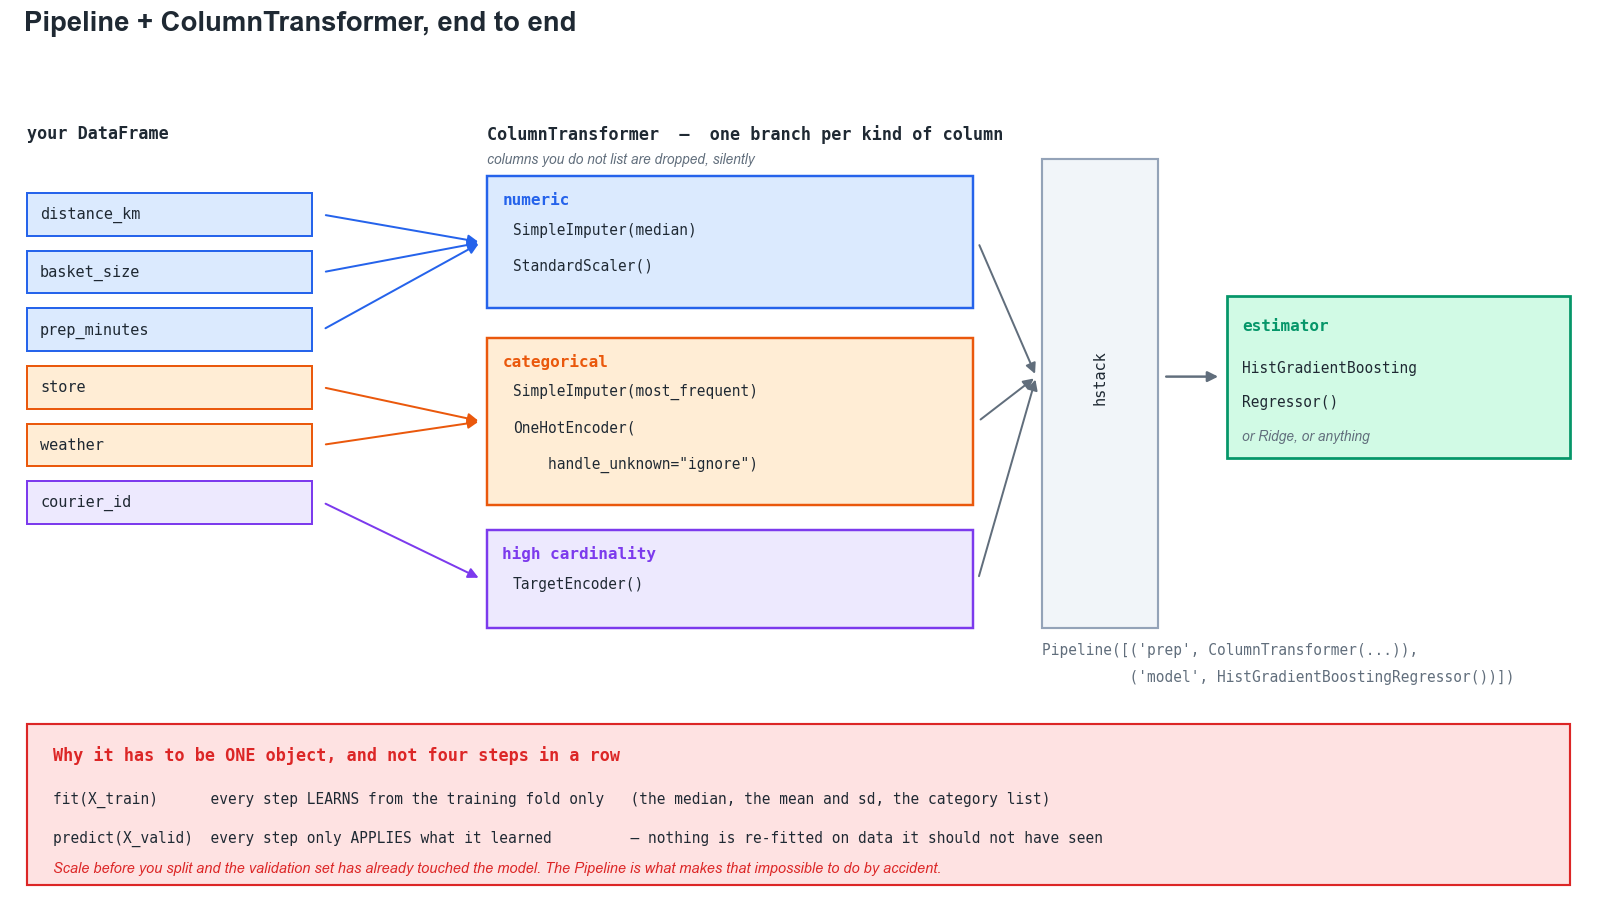

In [15]:
pipeline_anatomy();   # also assets/pipeline_anatomy.png

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

NUMERIC = ["distance_km", "prep_minutes", "basket_size", "basket_value_toman"]
CATEGORICAL = ["store", "courier_type", "weather"]

preprocess = ColumnTransformer([
    # (name, what to do, which columns)
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), NUMERIC),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore",
                                               sparse_output=False))]), CATEGORICAL),
])
# Columns you do not name are dropped. That is the safe default: nothing gets
# near the model by accident.

out = preprocess.fit_transform(deliveries[NUMERIC + CATEGORICAL])
print(f"{len(NUMERIC + CATEGORICAL)} columns in  ->  {out.shape[1]} columns out")
print("names out:", list(preprocess.get_feature_names_out())[:6], "...")
preprocess

7 columns in  ->  13 columns out
names out: ['num__distance_km', 'num__prep_minutes', 'num__basket_size', 'num__basket_value_toman', 'cat__store_Gohardasht', 'cat__store_Punak'] ...


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['distance_km', 'prep_minutes', 'basket_size',
                                  'basket_value_toman']),
                                ('cat',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['store', 'courier_type', 'weather'])])

That display is interactive — click through it in your own notebook. It is the
fastest way to confirm you built what you meant to build.

In [17]:
# Proof that a Pipeline actually prevents the mistake. We deliberately give
# the "wrong" version the whole dataset to learn its median from.
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

FEATURES = NUMERIC + CATEGORICAL
train, test = train_test_split(deliveries, test_size=0.2, random_state=SEED)

# WRONG: impute using statistics computed over train AND test together.
all_rows = pd.concat([train, test])
leaky_imputer = SimpleImputer(strategy="median").fit(all_rows[NUMERIC])
print("median learned from everything:", leaky_imputer.statistics_.round(3))

# RIGHT: the Pipeline only ever sees the training fold in fit().
clean_imputer = SimpleImputer(strategy="median").fit(train[NUMERIC])
print("median learned from train only:", clean_imputer.statistics_.round(3))
print("\nHere the two are nearly identical, so the damage is small -- but you")
print("do not get to know that in advance, and with a scaler on a skewed")
print("column or a rare category the gap can be large.")

median learned from everything: [2.410e+00 6.600e+00 4.000e+00 4.745e+05]
median learned from train only: [2.40e+00 6.60e+00 4.00e+00 4.77e+05]

Here the two are nearly identical, so the damage is small -- but you
do not get to know that in advance, and with a scaler on a skewed
column or a rare category the gap can be large.


The point is not that this particular leak is big. It is that a `Pipeline`
makes it **impossible**, so you never have to check.

### 💡 Try it yourself

10. Add a third branch that drops a column entirely with `"drop"`.
11. Call `preprocess.named_transformers_["num"]` — you can reach inside a
    fitted pipeline and inspect any step.
12. Swap `HistGradientBoostingRegressor` for `Ridge` in the model below.
    How many lines change?

---

# 5. Fitting a model, and something to beat

Fitting is three lines and the least interesting part of the day. What matters
is the number next to it.

**Always start with a baseline** — something the business could do without you.
A model that cannot beat "predict the median" is not a model.

In [18]:
from sklearn.dummy import DummyRegressor

TARGET = "delivery_minutes"

baseline = DummyRegressor(strategy="median").fit(train[FEATURES], train[TARGET])
baseline_mae = mean_absolute_error(test[TARGET], baseline.predict(test[FEATURES]))

# The whole pipeline is a single estimator: this one fit() runs the imputers,
# the scaler, the encoder and the model, all learning from `train` only.
model = Pipeline([
    ("prep", preprocess),
    ("model", HistGradientBoostingRegressor(random_state=SEED)),
])
model.fit(train[FEATURES], train[TARGET])
model_mae = mean_absolute_error(test[TARGET], model.predict(test[FEATURES]))

print(f"always predict {baseline.constant_[0][0]:.1f} minutes -> MAE {baseline_mae:.2f}")
print(f"gradient boosting                  -> MAE {model_mae:.2f}")
print(f"improvement: {(1 - model_mae / baseline_mae) * 100:.0f}%")

always predict 20.3 minutes -> MAE 6.72
gradient boosting                  -> MAE 4.81
improvement: 28%


In [19]:
from sklearn.model_selection import cross_validate, KFold

# One number from one split is not a result. cross_validate refits the whole
# pipeline on each fold -- preprocessing included -- which is the only reason
# the score means anything.
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
scores = cross_validate(model, train[FEATURES], train[TARGET], cv=cv,
                        scoring="neg_mean_absolute_error", return_train_score=True)

fold_mae = -scores["test_score"]
print("fold MAEs:", fold_mae.round(2))
print(f"\ncross-validated: {fold_mae.mean():.2f}  +/- {fold_mae.std():.2f}")
print(f"on the training folds: {-scores['train_score'].mean():.2f}"
      "   (much lower would mean overfitting)")

fold MAEs: [5.05 5.   5.1  4.85 5.07]

cross-validated: 5.01  +/- 0.09
on the training folds: 4.33   (much lower would mean overfitting)


Quote the spread alongside the mean. "4.9 ± 0.1" and "4.9 ± 0.8" are not the
same model, and a 0.05 improvement over a competitor means nothing if your
folds disagree by 0.8.

### 💡 Try it yourself

13. Try `DummyRegressor(strategy="mean")`. Why is the median better here?
14. Set `max_iter=1000` on the booster. Does the CV score improve? Does the
    *train* score? What does the gap tell you?
15. Run the CV twice with different `random_state` on the `KFold`. How much
    does the mean move? Is your model comparison bigger than that?

---

# 6. Four ways a score lies to you

This is the long section and the one worth your attention. Every scenario is a
real mistake; I have made two of them myself and one of them shipped.

**Guess before I run each cell.** A minute with the person next to you, then we
look. The guessing is the part that sticks.

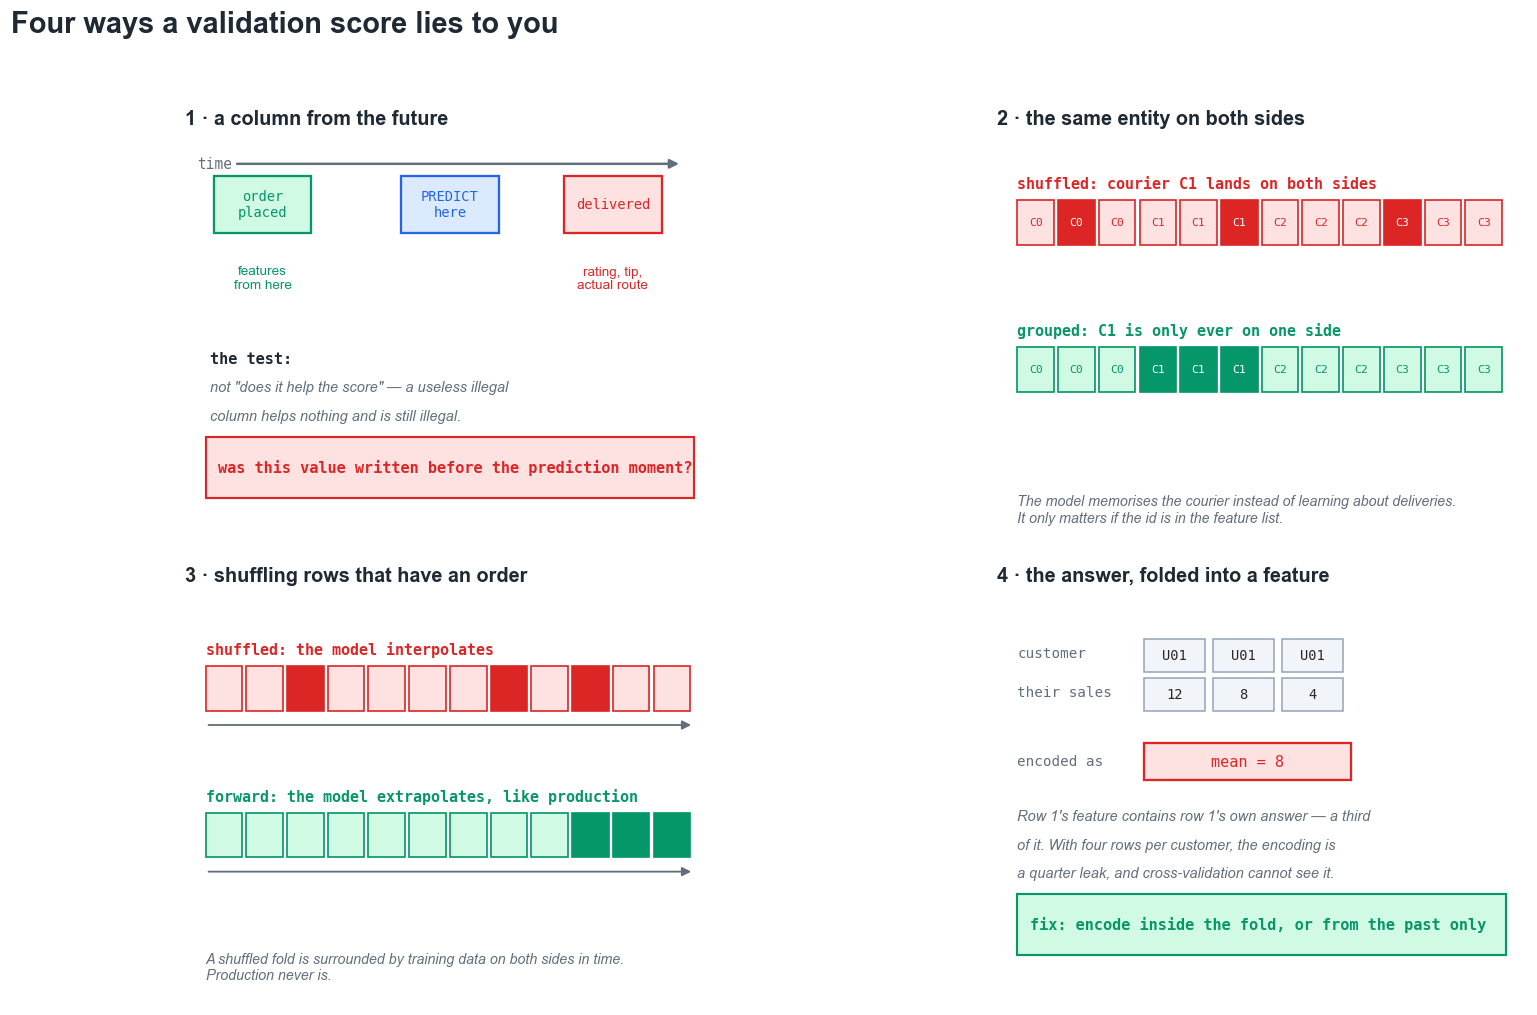

In [20]:
leakage_gallery();   # also assets/leakage_gallery.png

In [21]:
# One helper, reused for every experiment below, so only the thing being
# tested ever changes.
def build_pipeline(numeric, categorical):
    return Pipeline([
        ("prep", ColumnTransformer([
            ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                              ("scale", StandardScaler())]), numeric),
            ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                              ("onehot", OneHotEncoder(handle_unknown="ignore",
                                                       sparse_output=False))]),
             categorical)])),
        ("model", HistGradientBoostingRegressor(random_state=SEED)),
    ])


def cv_mae(pipe, X, target, cv=cv, groups=None):
    """Cross-validated MAE, positive, in minutes."""
    from sklearn.model_selection import cross_val_score
    return -cross_val_score(pipe, X, target, cv=cv, groups=groups,
                            scoring="neg_mean_absolute_error").mean()


y = deliveries[TARGET]
honest = cv_mae(build_pipeline(NUMERIC, CATEGORICAL), deliveries[FEATURES], y)
print(f"our honest number so far: {honest:.2f} min")

our honest number so far: 4.95 min


## Leak 1 — a column that did not exist yet

Three columns in this table are recorded **after** the delivery finishes:
`actual_route_km` (the distance actually ridden), `rating` and `tip_toman`.
None of them exists when the order is placed.

What would taking them have bought us?

In [22]:
rows = [{"features": "honest", "cv_mae": honest}]
for illegal in ["actual_route_km", "rating", "tip_toman"]:
    mae = cv_mae(build_pipeline(NUMERIC + [illegal], CATEGORICAL),
                 deliveries[FEATURES + [illegal]], y)
    rows.append({"features": f"+ {illegal}", "cv_mae": mae})

table = pd.DataFrame(rows)
table["vs honest"] = (1 - table["cv_mae"] / honest).map("{:+.0%}".format)
print(table.round(2).to_string(index=False))

         features  cv_mae vs honest
           honest    4.95       +0%
+ actual_route_km    4.12      +17%
         + rating    3.68      +26%
      + tip_toman    4.94       +0%


Read the `tip_toman` row carefully, because it is the point of the table.

`rating` and `actual_route_km` make the model look dramatically better — of
course they do, they are half the answer. **`tip_toman` changes nothing**, and
it is exactly as illegal as the other two.

> **"Does it improve the score" is not the test. "Was it available at
> prediction time" is.**

Use the score as your filter and you keep every leak that helps, and you keep
the useless illegal columns too. The only reliable filter is walking the column
list and asking, one at a time, *when each value gets written*.

**At work:** ask the engineer who owns the table when each column is
populated. Not what it means — when it is written. Twenty minutes, and it is
the highest-value twenty minutes of the project.

## Leak 2 — the same entity on both sides

In [23]:
counts = deliveries["courier_id"].value_counts()
print(f"{deliveries['courier_id'].nunique()} couriers over {len(deliveries):,} orders")
print(f"orders per courier: median {counts.median():.0f}, max {counts.max()}")

# courier_id passes the availability test -- dispatch assigns the courier when
# the order is placed. And couriers really do differ in speed. So: add it.
CAT_ID = CATEGORICAL + ["courier_id"]
X_id = deliveries[FEATURES + ["courier_id"]]
shuffled = cv_mae(build_pipeline(NUMERIC, CAT_ID), X_id, y)
print(f"\nwith courier_id, ordinary KFold: {shuffled:.2f} min"
      f"   ({(1 - shuffled / honest):+.0%} vs honest)")

200 couriers over 12,000 orders
orders per courier: median 43, max 317



with courier_id, ordinary KFold: 4.30 min   (+13% vs honest)


In [24]:
from sklearn.model_selection import GroupKFold

# Same pipeline, same features, same data. The only change is `groups`, which
# tells the splitter to keep all of a courier's rows on one side.
grouped = cv_mae(build_pipeline(NUMERIC, CAT_ID), X_id, y,
                 cv=GroupKFold(n_splits=5), groups=deliveries["courier_id"])

print(f"random KFold : {shuffled:.2f} min   <- the flattering number")
print(f"GroupKFold   : {grouped:.2f} min   <- what a NEW courier gets")
print(f"no courier_id at all: {honest:.2f} min")
print(f"\nthe shuffle was hiding {grouped - shuffled:+.2f} min")

random KFold : 4.30 min   <- the flattering number
GroupKFold   : 4.91 min   <- what a NEW courier gets
no courier_id at all: 4.95 min

the shuffle was hiding +0.61 min


So `courier_id` is worth far less than the shuffled folds claimed — close to
nothing, measured honestly.

**Which number is right depends on the world, not on statistics:** will the
couriers you predict for tomorrow be the couriers you trained on? A stable
fleet → the random number is closer. High turnover → `GroupKFold` is the honest
estimate. You cannot answer that from the dataframe; you ask operations.

The pattern is "repeated units": the patient not the scan, the customer not the
loan, the speaker not the utterance, the machine not the part.

**And note the second condition.** Group leakage needs the entity on both sides
**and** something in the features that identifies it. Drop `courier_id` from
the column list and grouping changes almost nothing — try it.

## Leak 3 — shuffling rows that have an order

In [25]:
from sklearn.model_selection import TimeSeriesSplit

ordered = deliveries.sort_values("order_time").reset_index(drop=True)
y_ord = ordered[TARGET]
pipe = build_pipeline(NUMERIC, CATEGORICAL)

shuffled_cv = cv_mae(pipe, ordered[FEATURES], y_ord)
forward_cv = cv_mae(pipe, ordered[FEATURES], y_ord, cv=TimeSeriesSplit(n_splits=5))

# The strictest test available: train on the first 80% of history, predict the
# last 20%. The closest thing to deploying it and waiting.
cut = int(len(ordered) * 0.8)
past, future = ordered.iloc[:cut], ordered.iloc[cut:]
fitted = pipe.fit(past[FEATURES], past[TARGET])
future_mae = mean_absolute_error(future[TARGET], fitted.predict(future[FEATURES]))

print(f"shuffled KFold              : {shuffled_cv:.2f} min")
print(f"TimeSeriesSplit             : {forward_cv:.2f} min  ({forward_cv/shuffled_cv-1:+.0%})")
print(f"train on past, score future : {future_mae:.2f} min  ({future_mae/shuffled_cv-1:+.0%})")

shuffled KFold              : 4.95 min
TimeSeriesSplit             : 5.45 min  (+10%)
train on past, score future : 6.09 min  (+23%)


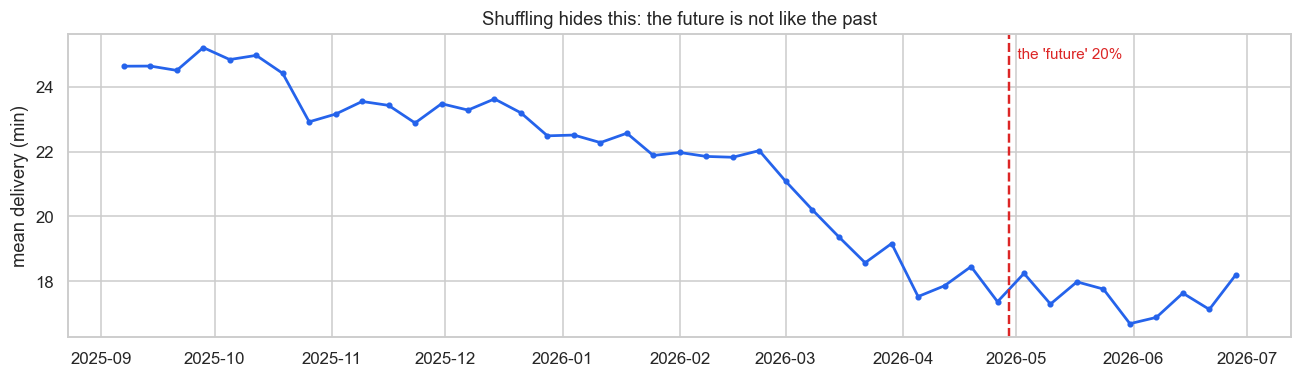

In [26]:
# Why the gap exists, in one picture: the thing we predict moved over time.
fig, ax = plt.subplots(figsize=(12, 3.6))
weekly = ordered.set_index("order_time")[TARGET].resample("W").mean()
ax.plot(weekly.index, weekly.values, color="#2563eb", lw=1.8, marker="o", ms=3)
ax.axvline(ordered.loc[cut, "order_time"], color="#dc2626", ls="--", lw=1.6)
ax.text(ordered.loc[cut, "order_time"], weekly.max(), "  the 'future' 20%",
        color="#dc2626", va="top", fontsize=10)
ax.set(ylabel="mean delivery (min)",
       title="Shuffling hides this: the future is not like the past")
fig.tight_layout()

Two things people get wrong right after learning this:

- **`TimeSeriesSplit` also trains on less data**, so part of its worse score is
  smaller training sets rather than genuine difficulty. The
  train-on-past/score-on-future number is the one to quote.
- **A time split is not always right.** If the rows genuinely have no order,
  shuffling is correct and a time split throws away data for nothing.

## Leak 4 — the answer, folded into a feature

The worst one, because the code looks careful.

Suppose we encode each customer by their average delivery time. Sensible: some
customers live in awkward buildings. And we are careful — we compute the
encoding on the **training set only**.

In [27]:
train_df, test_df = train_test_split(deliveries, test_size=0.2, random_state=SEED)

# Compute the encoding on TRAINING data only. This feels safe. It is not.
encoding = train_df.groupby("customer_id")[TARGET].mean()
fallback = train_df[TARGET].mean()

train_enc = train_df.assign(customer_mean=train_df["customer_id"].map(encoding))
test_enc = test_df.assign(
    customer_mean=test_df["customer_id"].map(encoding).fillna(fallback))

WITH_TE = FEATURES + ["customer_mean"]
cv_without = cv_mae(build_pipeline(NUMERIC, CATEGORICAL),
                    train_df[FEATURES], train_df[TARGET])
cv_with = cv_mae(build_pipeline(NUMERIC + ["customer_mean"], CATEGORICAL),
                 train_enc[WITH_TE], train_enc[TARGET])

print(f"cross-validated MAE without customer_mean : {cv_without:.2f} min")
print(f"cross-validated MAE with    customer_mean : {cv_with:.2f} min")
print(f"     -> {(1 - cv_with / cv_without) * 100:+.0f}%, our best feature yet")

cross-validated MAE without customer_mean : 5.01 min
cross-validated MAE with    customer_mean : 4.53 min
     -> +10%, our best feature yet


In [28]:
# Now spend the test set. This is the one look we get, and the only number
# here that the encoding could not possibly have seen.
fitted_te = build_pipeline(NUMERIC + ["customer_mean"], CATEGORICAL).fit(
    train_enc[WITH_TE], train_enc[TARGET])
holdout_with = mean_absolute_error(test_enc[TARGET], fitted_te.predict(test_enc[WITH_TE]))

fitted_plain = build_pipeline(NUMERIC, CATEGORICAL).fit(train_df[FEATURES], train_df[TARGET])
holdout_without = mean_absolute_error(test_df[TARGET], fitted_plain.predict(test_df[FEATURES]))

print(pd.DataFrame([
    {"model": "without customer_mean", "CV": cv_without, "holdout": holdout_without},
    {"model": "with customer_mean", "CV": cv_with, "holdout": holdout_with},
]).round(2).to_string(index=False))
print(f"\nCV said the feature was worth {(1 - cv_with/cv_without)*100:+.0f}%")
print(f"the holdout says it is worth   {(1 - holdout_with/holdout_without)*100:+.0f}%")

                model   CV  holdout
without customer_mean 5.01     4.81
   with customer_mean 4.53     5.59

CV said the feature was worth +10%
the holdout says it is worth   -16%


### Why

Each customer has about four orders. The encoding for a customer is the mean of
their four delivery times — **including the row we are about to predict**. So
roughly a quarter of the feature is the row's own answer, handed back to it.

Cross-validation cannot see this, because the contamination happened *before*
the folds were made. Every fold inherits the same poisoned column.

And the finishing blow: **`customer_id` has no relationship to delivery time in
this dataset at all.** Customers were assigned at random when the data was
generated; they are not in the formula. A column containing literally zero
information looked like the best feature in the model.

In [29]:
from sklearn.preprocessing import TargetEncoder

# TargetEncoder cross-fits internally: each row's encoding comes from folds
# that exclude it. And because it lives inside the Pipeline, it is refitted
# on each CV fold too.
pipe_te = Pipeline([
    ("prep", ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale", StandardScaler())]), NUMERIC),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore",
                                                   sparse_output=False))]), CATEGORICAL),
        ("te", TargetEncoder(random_state=SEED), ["customer_id"])])),
    ("model", HistGradientBoostingRegressor(random_state=SEED)),
])
COLS_TE = FEATURES + ["customer_id"]
cv_proper = cv_mae(pipe_te, train_df[COLS_TE], train_df[TARGET])
holdout_proper = mean_absolute_error(
    test_df[TARGET], pipe_te.fit(train_df[COLS_TE], train_df[TARGET]).predict(test_df[COLS_TE]))

print(pd.DataFrame([
    {"approach": "no customer feature", "CV": cv_without, "holdout": holdout_without},
    {"approach": "hand-rolled encoding", "CV": cv_with, "holdout": holdout_with},
    {"approach": "TargetEncoder in the Pipeline", "CV": cv_proper, "holdout": holdout_proper},
]).round(2).to_string(index=False))

                     approach   CV  holdout
          no customer feature 5.01     4.81
         hand-rolled encoding 4.53     5.59
TargetEncoder in the Pipeline 5.00     4.82


The third row is the result you want. Not a better number — an **honest** one.
Both columns agree that this feature is worth nothing, which is exactly right,
and that agreement is what stopped it shipping.

Target encoding is a good tool for genuine high-cardinality categories. It just
has to be cross-fitted, and it has to live inside the pipeline. On time-series
data there is a different correct version — encode from the past only — and
notebook 05 shows it.

### 💡 Try it yourself

16. Redo leak 2 with `customer_id` as the group instead of `courier_id`. Does
    the score move? Explain why or why not in one sentence.
17. In leak 4, give each customer 40 orders instead of 4 (sample with
    replacement). Does the leak get bigger or smaller?
18. Add `actual_route_km` and then run `GroupKFold`. Does a better split
    protect you from a leaky column? (It does not — they are different
    problems.)

---

# 7. Which cross-validation split

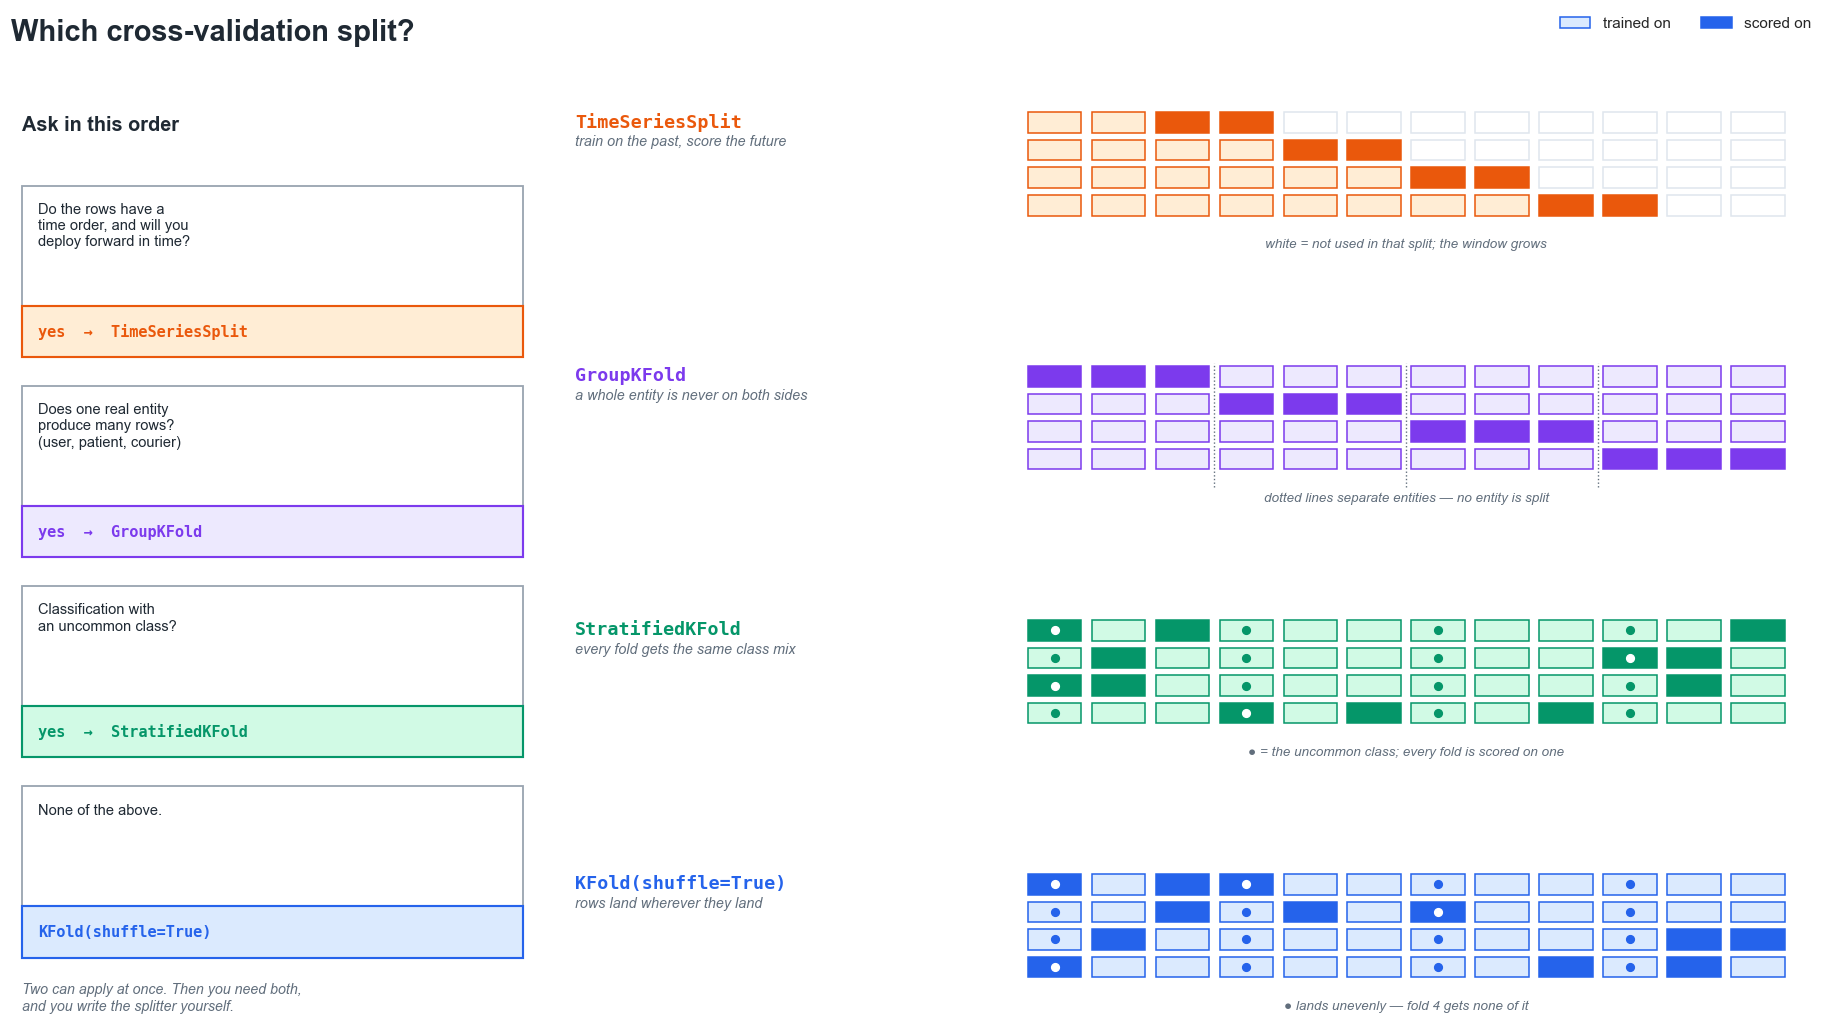

In [30]:
cv_schemes();   # also assets/cv_schemes.png

Four leaks, three of which were the same question in different clothes:
**what does my validation fold have to look like for the score to mean what I
think it means?**

A four-step procedure that covers most cases:

1. **Is there a time order and will you deploy forward?** → `TimeSeriesSplit`,
   and quote a train-on-past / score-on-future number.
2. **Does one real entity produce many rows?** → `GroupKFold` on that entity.
3. **Classification with an uncommon class?** → `StratifiedKFold`.
4. **None of the above** → `KFold(shuffle=True)`.

Steps 1 and 2 can both apply. sklearn has no built-in splitter for that
combination; you write it, and notebook 05 has the real case.

---

# 8. Metrics

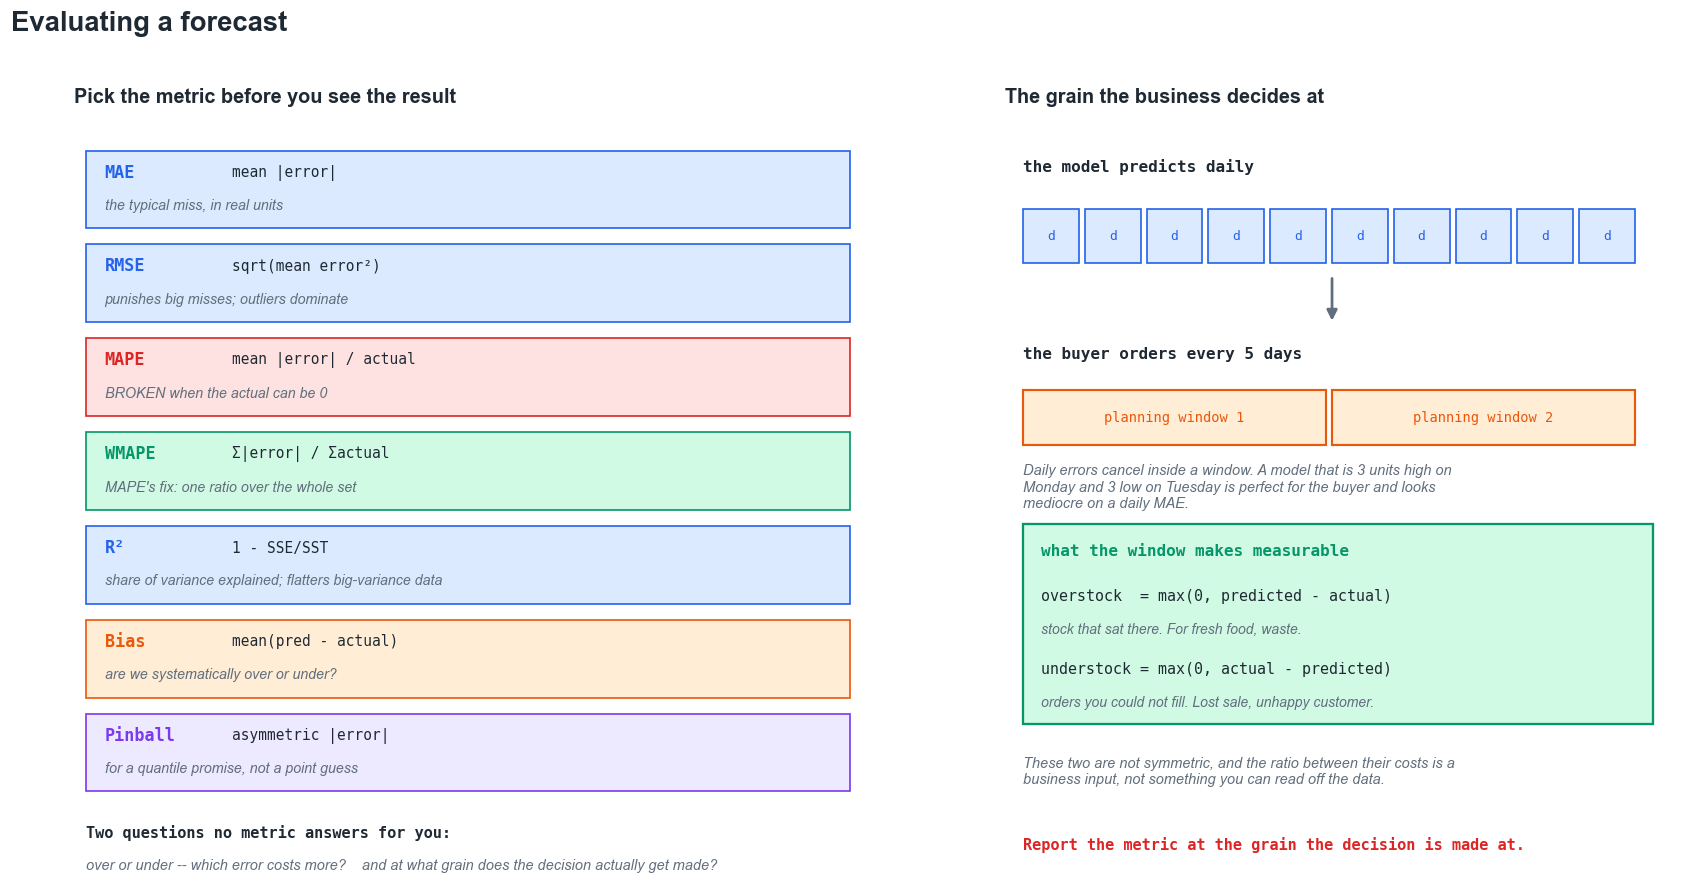

In [31]:
metrics_sheet();   # also assets/metrics_sheet.png

In [32]:
from sklearn.metrics import mean_squared_error, r2_score

pred = fitted_plain.predict(test_df[FEATURES])
truth = test_df[TARGET].to_numpy()

print(f"MAE  : {mean_absolute_error(truth, pred):.2f} minutes")
print(f"RMSE : {np.sqrt(mean_squared_error(truth, pred)):.2f} minutes")
print(f"R2   : {r2_score(truth, pred):.3f}")
print(f"bias : {(pred - truth).mean():+.2f} minutes  (are we systematically over or under?)")

# WMAPE: one ratio over the whole set. MAPE would divide by each actual,
# which explodes the moment an actual is near zero.
print(f"WMAPE: {np.abs(truth - pred).sum() / truth.sum() * 100:.1f}%")

MAE  : 4.81 minutes
RMSE : 6.25 minutes
R2   : 0.468
bias : -0.19 minutes  (are we systematically over or under?)
WMAPE: 22.4%


In [33]:
# RMSE vs MAE, made concrete: one bad prediction moves them very differently.
# Both predictions are off by 10 units in total, spread differently.
a = np.array([10.0, 10, 10, 10, 10])
small_errors = np.array([12.0, 8, 12, 8, 10])      # off by 2 four times
one_disaster = np.array([10.0, 10, 10, 10, 20])    # perfect, then 10 out

for name, p in [("many small errors", small_errors), ("one big error", one_disaster)]:
    print(f"{name:20} MAE {mean_absolute_error(a, p):5.2f}   "
          f"RMSE {np.sqrt(mean_squared_error(a, p)):5.2f}")
print("\nSame MAE, very different RMSE. Choose the one that matches what hurts:")
print("if one 40-minute delivery is worse than eight 5-minute ones, use RMSE.")

many small errors    MAE  1.60   RMSE  1.79
one big error        MAE  2.00   RMSE  4.47

Same MAE, very different RMSE. Choose the one that matches what hurts:
if one 40-minute delivery is worse than eight 5-minute ones, use RMSE.


The right-hand panel of that sheet is the one people skip and then regret.
**The grain you evaluate at can reverse which model wins** — notebook 05 has a
case where the dumbest model on the list looks best until you fix the grain,
and then does not.

### 💡 Try it yourself

19. Compute MAPE by hand on the test set. What happens as actuals approach
    zero? Why is WMAPE the usual fix?
20. `r2_score` on a single fold vs the full test set — do they agree? What does
    R² depend on that MAE does not?

---

# 9. Error analysis

The overall number tells you the size of the problem. It never tells you what
the problem is.

                   mae  bias
delivery_minutes            
(0, 15]           5.02  4.63
(15, 20]          3.73  1.55
(20, 25]          3.62  0.08
(25, 32]          4.58 -3.25
(32, 200]         9.75 -9.57


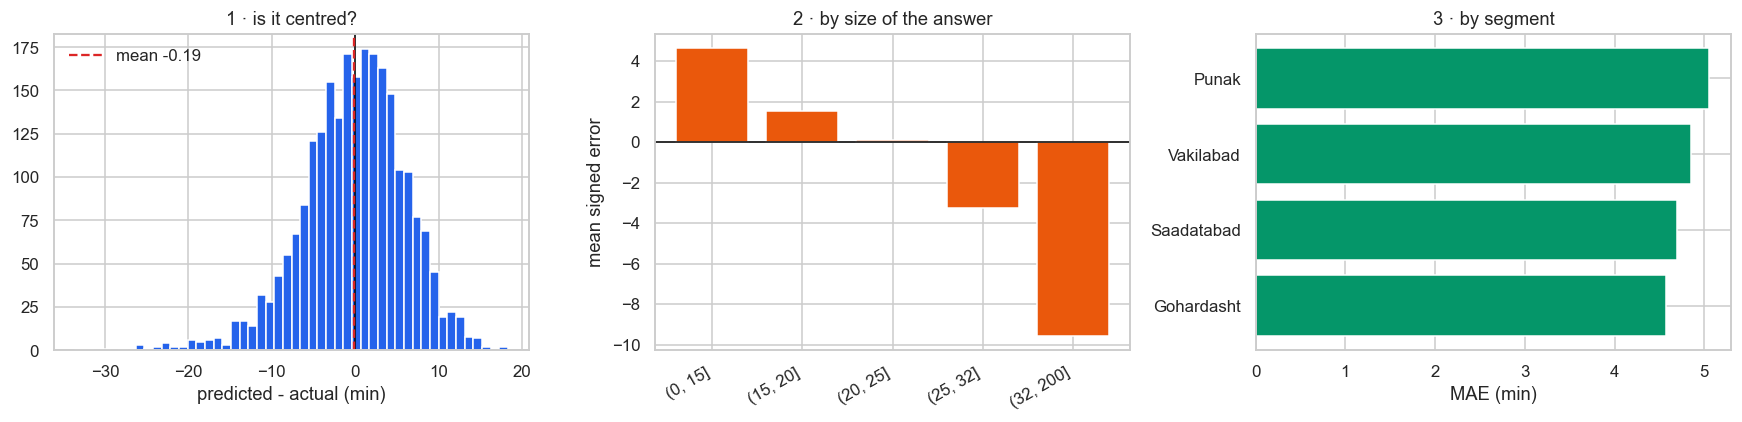

In [34]:
errors = test_df.copy()
errors["pred"] = pred
errors["error"] = errors["pred"] - errors[TARGET]

fig, (ax_dist, ax_size, ax_seg) = plt.subplots(1, 3, figsize=(16, 4))

# 1. Are the errors centred, or is the model biased?
ax_dist.hist(errors["error"], bins=50, color="#2563eb")
ax_dist.axvline(0, color="black", lw=1)
ax_dist.axvline(errors["error"].mean(), color="#dc2626", ls="--",
                label=f"mean {errors['error'].mean():+.2f}")
ax_dist.set(xlabel="predicted - actual (min)", title="1 · is it centred?")
ax_dist.legend(frameon=False)

# 2. Does the error depend on the size of the answer? Almost always yes.
bands = pd.cut(errors[TARGET], [0, 15, 20, 25, 32, 200])
by_size = errors.groupby(bands, observed=True).agg(
    mae=("error", lambda e: e.abs().mean()), bias=("error", "mean"))
ax_size.bar(range(len(by_size)), by_size["bias"], color="#ea580c")
ax_size.axhline(0, color="black", lw=1)
ax_size.set(xticks=range(len(by_size)), ylabel="mean signed error",
            title="2 · by size of the answer")
ax_size.set_xticklabels([str(i) for i in by_size.index], rotation=30, ha="right")

# 3. Which segments are worst? Sorted -- unsorted bars hide the answer.
by_store = (errors.groupby("store")["error"].apply(lambda e: e.abs().mean())
            .sort_values())
ax_seg.barh(by_store.index, by_store.values, color="#059669")
ax_seg.set(xlabel="MAE (min)", title="3 · by segment")
fig.tight_layout()
print(by_size.round(2).to_string())

The middle panel is the one that always shows something. **The model
over-predicts the fast deliveries and under-predicts the slow ones** — it is
pulled toward the middle, which is what minimising average error asks for.

That is not a bug to tune away; it is the shape of the problem. And it has a
concrete consequence: if the number goes on a customer's screen as a promise,
a point estimate is the wrong output. A quantile is.

In [35]:
# Read the actual rows. Aggregates tell you the size, rows tell you the shape.
worst = errors.reindex(errors["error"].abs().sort_values(ascending=False).index).head(8)
print(worst[["store", "courier_type", "weather", "distance_km",
             TARGET, "pred", "error"]].round(1).to_string(index=False))

share = errors["error"].abs().nlargest(int(len(errors) * 0.01)).sum()
print(f"\nthe worst 1% of orders carry {share / errors['error'].abs().sum():.0%}"
      " of the total absolute error")

     store courier_type weather  distance_km  delivery_minutes  pred  error
     Punak   motorcycle    rain          5.3              65.3  31.8  -33.5
 Vakilabad      bicycle    rain          3.9              63.8  32.3  -31.5
     Punak      bicycle   clear          3.3              54.7  24.5  -30.2
Saadatabad      bicycle   clear          3.3              52.6  24.6  -28.0
 Vakilabad      bicycle   clear          2.5              49.4  23.2  -26.2
     Punak   motorcycle   clear          3.0              48.1  22.7  -25.4
Saadatabad   motorcycle   clear          3.4              49.7  24.4  -25.3
Saadatabad      bicycle   clear          1.5              42.6  17.8  -24.8

the worst 1% of orders carry 5% of the total absolute error


Almost all of them are slow deliveries the model called ordinary — the
incidents built into this dataset. **More feature engineering will not fix
those.** They would need signal from outside the table: live traffic, whether
the courier was already carrying another order, whether the building has a
lift.

Saying that out loud is the deliverable. "The model is good to about ±4 minutes
except on the 2% of orders where something goes wrong, and we cannot see those
in this data" is a far more useful sentence than any single number.

---

## What to carry out of this notebook

1. **One interface.** `fit` / `transform` / `predict`, everywhere.
2. **Split first, and put everything that learns inside the Pipeline.**
3. **Baseline before model.** A number to beat, or you cannot tell.
4. **The leakage test is availability, not score.** Ask when the column is
   written.
5. **Match the split to how the model is used.** Time, groups, or neither.
6. **Choose the metric before you see the result**, and check the grain.
7. **Say what it is bad at** before anyone asks.

Notebook 05 puts all seven on a real problem where each one cost something.